# Predicting Recipe Origin from Ingredients

**Name(s)**: Coleman Clougherty and Jamera Fernando

**Website Link**: https://colecamc.github.io/recipes-predictive-project/

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

import plotly.express as px
pd.options.plotting.backend = 'plotly'

from dsc80_utils import * # Feel free to uncomment and use this.
import re
import matplotlib.pyplot as plt
from tqdm import trange
from sklearn.linear_model import LinearRegression

## Step 1: Introduction

Our data comes from food.com, which is a platform where users can publically submit personalized recipes to learn from, rate, and review them. One of the features of food.com is that each recipe has different tags that describe the kind of dishes they are (e.g. 'salsas', 'nut-free', 'french'). Given this, we wanted to investigate the question: **what is the relationship between features, such as cooking time, ingredients, and calories, with continent of origin for different recipes?**


## Step 2: Data Cleaning and Exploratory Data Analysis

In [ ]:
interactions = pd.read_csv(Path('data') /'RAW_interactions.csv')
recipes = pd.read_csv(Path('data') / 'RAW_recipes.csv')

In [ ]:
recipes['nutrition']

0            [138.4, 10.0, 50.0, 3.0, 3.0, 19.0, 6.0]
1        [595.1, 46.0, 211.0, 22.0, 13.0, 51.0, 26.0]
2           [194.8, 20.0, 6.0, 32.0, 22.0, 36.0, 3.0]
                             ...                     
83779            [59.2, 6.0, 2.0, 3.0, 6.0, 5.0, 0.0]
83780       [188.0, 11.0, 57.0, 11.0, 7.0, 21.0, 9.0]
83781        [174.9, 14.0, 33.0, 4.0, 4.0, 11.0, 6.0]
Name: nutrition, Length: 83782, dtype: object

In [ ]:
recipes['tags']

0        ['60-minutes-or-less', 'time-to-make', 'course...
1        ['60-minutes-or-less', 'time-to-make', 'cuisin...
2        ['60-minutes-or-less', 'time-to-make', 'course...
                               ...                        
83779    ['60-minutes-or-less', 'time-to-make', 'course...
83780    ['30-minutes-or-less', 'time-to-make', 'course...
83781    ['30-minutes-or-less', 'time-to-make', 'course...
Name: tags, Length: 83782, dtype: object

In [ ]:
recipes.columns

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients'],
      dtype='object')

In [ ]:
interactions['recipe_id'].sort_values()

70222         38
70223         38
70221         38
           ...  
475342    537543
277439    537671
295955    537716
Name: recipe_id, Length: 731927, dtype: int64

In [ ]:
interactions[interactions['review'].isna()].describe()

,user_id,recipe_id,rating
count,1.69e+02,169.00,169.00
mean,1.83e+09,214467.93,4.72
std,5.52e+08,163237.62,0.70
...,...,...,...
50%,2.00e+09,166775.00,5.00
75%,2.00e+09,356724.00,5.00
max,2.00e+09,533896.00,5.00


We created our merged recipes data sets and replaced average ratings that had 0 with np.nan

In [ ]:
merged = recipes.merge(interactions, left_on='id',\
                        right_on='recipe_id', how='left')
merged.loc[merged['rating'] == 0, 'rating'] = np.nan
avg_rating = merged.groupby('id')['rating'].mean()
avg_rating

recipes2 = recipes.merge(avg_rating.rename('avg_rating'),\
                          left_on='id', right_index=True, how='left')
# recipes[recipes['avg_rating'].notnull()]
recipes2.columns

Index(['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags',
       'nutrition', 'n_steps', 'steps', 'description', 'ingredients',
       'n_ingredients', 'avg_rating'],
      dtype='object')

The tags column is a quote of a list of different tokens, so we wanted to canonicalize it and get each separate token. We then created a new column, 'tags_list' which transformed tags (quote) into a list of individually quoted tags. We want to do this to understand how the tags describe the recipes, and understanding the relationships specific tags may have with different features

In [ ]:
def tags_to_list(tags):
    pattern =r"'([\w-]*)'"
    unused = r"('(.*)',)|(, '(.*)')"
    return re.findall(pattern, tags)

recipes2['tags_list'] = recipes2['tags'].transform(tags_to_list)

df_extracted = recipes2['nutrition'].str.\
    findall(r"\d+\.\d*").apply(pd.Series)
df_extracted.columns = ['calories', 'total_fat', \
                        'sugar', 'sodium', 'protein', \
                            'saturated_fat', 'carbohydrates']
df_extracted

recipes3 = pd.concat([recipes2, df_extracted], \
                     axis=1).drop(columns=['nutrition', 'tags'])
recipes3['tags_list'].iloc[0]

['60-minutes-or-less',
 'time-to-make',
 'course',
 'main-ingredient',
 'preparation',
 'for-large-groups',
 'desserts',
 'lunch',
 'snacks',
 'cookies-and-brownies',
 'chocolate',
 'bar-cookies',
 'brownies',
 'number-of-servings']

Below is how one recipe's tag_list looks like, which is a list of tags that describes the recipe.

In [ ]:
recipes3['tags_list'].iloc[501]

['30-minutes-or-less',
 'time-to-make',
 'course',
 'main-ingredient',
 'cuisine',
 'preparation',
 'north-american',
 'main-dish',
 'beans',
 'vegetables',
 'mexican',
 'easy',
 'beginner-cook',
 'kid-friendly',
 'vegetarian',
 'dietary',
 'one-dish-meal',
 'inexpensive']

### Distribution of average_ratings in Recipes ###

Before feature engineering more columns for Data Analysis, we wanted to analyze different existing features in the dataset and how they relate to each other 

In [ ]:
recipes3['avg_rating'].hist(nbins=10)

As seen in the graph above, the distribution is unimodal with a strong skew to the left. Higher rated recipes usually have the highest amount of reviews; this could be because popular recipes, made by popular chefs for example, are more critically acclaimed and praised. In contrast, recipes with low views, specifically below 10k, have ratings that are average to poor. 

In [ ]:
px.histogram(recipes3, x='avg_rating', nbins=10, \
             title='Average Recipe Ratings', \
                labels={'avg_rating':'Average Rating', 'count':'Count'})

Average recipe ratings remain the same distribution as the raw distribution of recipe ratings.

In [ ]:
data = interactions.groupby('recipe_id')['rating'].count()

In [ ]:
px.box(data, x='rating', title='Number of Ratings per Recipe',\
        log_x=True, labels = {'rating':'Number of Ratings (scaled log)'})

Conclusion: The median number of recipes have a relatively lower number of ratings, however, there is a large variance to the dataset, with many recipes being an extreme outlier to the dataset. This shows the large gap between popular and unpopular recipes.

Since we wanted to investigate ingredients to see if there is a relationship between ingredients and continent, we transforms the list of ingredients into a list.  

In [ ]:
recipes3['ingredients'].transform(tags_to_list)

0                                          [eggs]
1         [salt, margarine, eggs, vanilla, water]
2                                    [salt, milk]
                           ...                   
83779                          [mayonnaise, salt]
83780    [butter, egg, extract, nutmeg, bisquick]
83781                   [shortening, eggs, flour]
Name: ingredients, Length: 83782, dtype: object

This was the target column that we wanted to analyze, and its relationship with other features in the dataset.

In [ ]:
continent_tags = [
    'north-american',
    'south-american',
    'european',
    'asian',
    'african',
    'australian'
]


In [ ]:
all_tags = [str(tag) for sublist in recipes2['tags_list'] \
            for tag in sublist]
unique_tags = list(set(all_tags))
unique_tags[:10]

['',
 'freshwater-fish',
 'mongolian',
 'chicken-stew',
 'stews',
 'chinese-new-year',
 'superbowl',
 'jewish-sephardi',
 'pasta-shells',
 'iranian-persian']

In [ ]:
def tag_contains(tags, name):
    name = name.lower()
    return name in tags

In [ ]:
for continent in continent_tags:
    print(continent, recipes3['tags_list'].apply(tag_contains, name=continent).sum())

north-american 14590
south-american 689
european 8897
asian 4575
african 1357
australian 1151


We created a dataframe with a column of the different continents. We created a dataframe that has the following columns:
-   ['id', 'continent_of_origin', 'value', 'name', 'minutes',
    'contributor_id', 'submitted', 'n_steps', 'steps', 'description',
   'ingredients', 'n_ingredients', 'avg_rating', 'tags_list', 'calories',
   'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat',
   'carbohydrates']

In [ ]:
continent_df = recipes3[['id', 'tags_list']].copy()
for continent in continent_tags:
    continent_df[continent] = continent_df['tags_list'].apply(tag_contains, name=continent)
continent_df = (continent_df.replace(False, np.nan)
              .melt(id_vars='id', value_vars=continent_tags)
              .dropna().drop_duplicates(subset='id')
)
continent_recipes = continent_df.merge(recipes3, left_on='id', \
                                       right_on='id', how='left').rename(columns={'variable':'continent_of_origin'})
continent_recipes

,id,continent_of_origin,value,name,...,sodium,protein,saturated_fat,carbohydrates
0,453467,north-american,True,1 in canada chocolate chip cookies,...,22.0,13.0,51.0,26.0
1,286009,north-american,True,millionaire pound cake,...,13.0,20.0,123.0,39.0
2,333797,north-american,True,rter med flsk pea soup with pork,...,34.0,44.0,12.0,0.0
...,...,...,...,...,...,...,...,...,...
29749,359208,australian,True,zucchini milano,...,1.0,2.0,0.0,1.0
29750,349024,australian,True,zucchini mustard chicken burgers,...,6.0,53.0,5.0,12.0
29751,441846,australian,True,zucchini feta and dill pie,...,47.0,50.0,69.0,7.0


In [ ]:
size_of_data = continent_recipes.shape[0]/recipes3.shape[0]
print(f'Size of continent_recipes is {size_of_data:.2%} of recipes3')

Size of continent_recipes is 35.51% of recipes3


### Univariate Analysis

In [ ]:
counts = continent_recipes['continent_of_origin'].value_counts().to_frame().reset_index()
counts
px.bar(counts, x='continent_of_origin', y='count',\
        labels={'count':'Count', 'continent_of_origin': 'Continent of Recipe Origin'})

This is the distribution of recipes of origins, with majority of the dishes being North-American. This may become an issue later on if we do a classification problem, as the data will be likely more biased towards north-american dishes due to the amount of data north-american dishes have. 

In [ ]:
recipes3['tags_list']

0        [60-minutes-or-less, time-to-make, course, mai...
1        [60-minutes-or-less, time-to-make, cuisine, pr...
2        [60-minutes-or-less, time-to-make, course, mai...
                               ...                        
83779    [60-minutes-or-less, time-to-make, course, mai...
83780    [30-minutes-or-less, time-to-make, course, pre...
83781    [30-minutes-or-less, time-to-make, course, pre...
Name: tags_list, Length: 83782, dtype: object

In [ ]:
all_tags = [str(tag) for sublist in recipes2['tags_list'] for tag in sublist]
unique_tags = list(set(all_tags))

In [ ]:
unique_tags[:10]

['',
 'freshwater-fish',
 'mongolian',
 'chicken-stew',
 'stews',
 'chinese-new-year',
 'superbowl',
 'jewish-sephardi',
 'pasta-shells',
 'iranian-persian']

In [ ]:
north_american = continent_recipes[continent_recipes['continent_of_origin'] == 'north-american']


In [ ]:
north_american['calories'] = north_american['calories'].astype(float)
north_american['total_fat'] = north_american['total_fat'].astype(float)

In [ ]:
north_american['total_fat'].describe()

count    14590.00
mean        35.13
std         66.62
           ...   
50%         21.00
75%         42.00
max       2899.00
Name: total_fat, Length: 8, dtype: float64

In [ ]:
north_american['calories_from_fat'] = north_american['total_fat'] * 0.78 * 9

In [ ]:
north_american['percent_calories_from_fat'] = \
    north_american['calories_from_fat'] / north_american['calories'] * 100

In [ ]:
north_american['percent_calories_from_fat'].hist(nbins=20)

In [ ]:
continent_recipes['calories'] = continent_recipes['calories'].astype(float)
continent_recipes['total_fat'] = continent_recipes['total_fat'].astype(float)
continent_recipes['calories_from_fat'] = continent_recipes['total_fat'] * 0.78 * 9
continent_recipes['percent_calories_from_fat'] = \
    continent_recipes['calories_from_fat'] / continent_recipes['calories'] * 100

def is_north_american(continent):
    if continent == 'north-american':
        return True
    else:
        return False

is_north_american_df = continent_recipes.assign\
    (is_north_american = continent_recipes['continent_of_origin'].apply(is_north_american))


In [ ]:
is_north_american_df.pivot_table(values='calories', index='is_north_american', aggfunc='mean')

,calories
is_north_american,
False,436.64
True,448.03


In [ ]:
continent_recipes.columns 

Index(['id', 'continent_of_origin', 'value', 'name', 'minutes',
       'contributor_id', 'submitted', 'n_steps', 'steps', 'description',
       'ingredients', 'n_ingredients', 'avg_rating', 'tags_list', 'calories',
       'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat',
       'carbohydrates', 'calories_from_fat', 'percent_calories_from_fat'],
      dtype='object')

In [ ]:
sns.set_style("whitegrid")
sns.set_palette("Set2")

def create_boxplots(df, features, category_col='continent_of_origin', figsize=(15, 10)):
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        
        data_clean = df[[feature, category_col]].dropna()
        
        sns.boxplot(data=data_clean, x=category_col, y=feature, ax=ax)
        ax.set_title(f'{feature} by Continent', fontsize=12, fontweight='bold')
        ax.set_xlabel('Continent', fontsize=10)
        ax.set_ylabel(feature, fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        
    for idx in range(n_features, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

def calculate_summary_stats(df, features, category_col='continent_of_origin'):
    results = []
    
    for feature in features:
        data_clean = df[[feature, category_col]].dropna()
        
        grouped = data_clean.groupby(category_col)[feature]
        
        stats_dict = {
            'Feature': feature,
            'Continent': [],
            'Count': [],
            'Mean': [],
            'Median': [],
            'Q1 (25%)': [],
            'Q3 (75%)': [],
            'IQR': [],
            'Std Dev': [],
            'Min': [],
            'Max': []
        }
        
        for continent, group in grouped:
            stats_dict['Continent'].append(continent)
            stats_dict['Count'].append(len(group))
            stats_dict['Mean'].append(group.mean())
            stats_dict['Median'].append(group.median())
            q1 = group.quantile(0.25)
            q3 = group.quantile(0.75)
            stats_dict['Q1 (25%)'].append(q1)
            stats_dict['Q3 (75%)'].append(q3)
            stats_dict['IQR'].append(q3 - q1)
            stats_dict['Std Dev'].append(group.std())
            stats_dict['Min'].append(group.min())
            stats_dict['Max'].append(group.max())
        
        results.append(pd.DataFrame(stats_dict))
    
    return pd.concat(results, ignore_index=True)


In [ ]:
numerical_features = ['calories', 'total_fat', 'minutes', 'n_ingredients', 'avg_rating'] 
stats = calculate_summary_stats(continent_recipes, numerical_features)
print(stats.to_string())

          Feature       Continent  Count    Mean  Median  Q1 (25%)  Q3 (75%)     IQR  Std Dev  Min      Max
0        calories         african   1222  442.31  314.80    176.10    535.98  359.88   719.70  0.1  18656.0
1        calories           asian   4316  404.42  318.75    173.47    507.70  334.23   412.92  0.0   9502.9
2        calories      australian    948  429.78  296.05    168.30    479.97  311.67   648.41  2.2   9702.6
3        calories        european   8060  453.52  343.15    194.17    561.23  367.05   542.93  0.0  17287.5
4        calories  north-american  14590  448.03  322.05    182.70    524.77  342.07   636.41  0.0  28930.2
5        calories  south-american    616  440.79  344.10    202.35    555.88  353.52   405.50  0.3   3333.6
6       total_fat         african   1222   35.90   18.50      7.00     41.00   34.00    96.31  0.0   2770.0
7       total_fat           asian   4316   30.75   20.00      7.00     37.00   30.00    45.98  0.0   1036.0
8       total_fat      austr

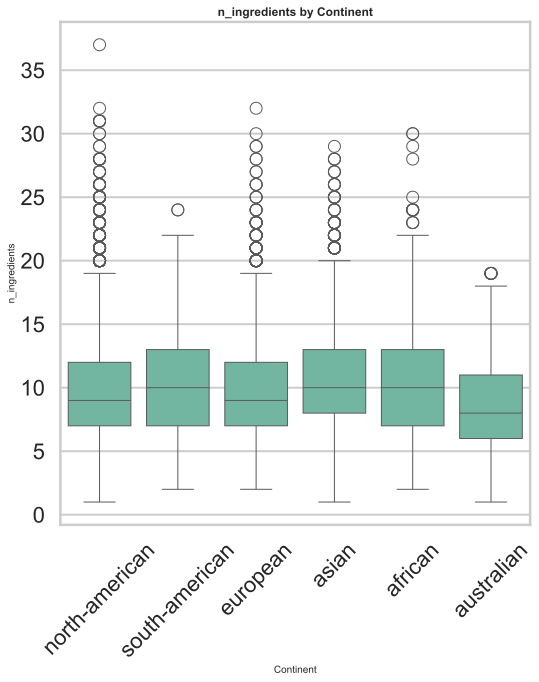

In [ ]:
create_boxplots(continent_recipes, ['n_ingredients'])

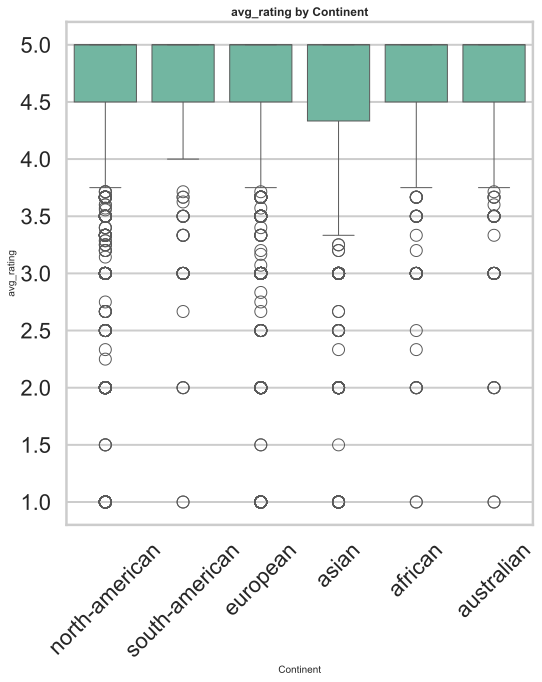

In [ ]:
create_boxplots(continent_recipes, ['avg_rating'])

#### Bivariate Analysis

We wanted to compare the distributions of Percent Calories from Fat in North American Recipes vs. Non-North American Recipes to investigate if there are any differences in healthiness between the continents. Since North America had the highest recipe count, we wanted to investigate using this continent. We decided on the engineering the column, 'percent_calories_from_fat,' as it standardized the amount of calories in recipes. 

In [ ]:
fig = px.histogram(is_north_american_df,
             x='percent_calories_from_fat',
             nbins = 20, 
             color='is_north_american', 
             barmode='overlay', 
             histnorm='probability density', 
             title='Distribution of Approximate Percent Calories \
                from Fat<br>in North American Recipes \
                    vs. Non-North American Recipes', 
             labels={'percent_calories_from_fat':'Percent Calories from Fat', \
                     'probability density':'Probability \
                        Density', 'is_american':'Is American Recipe?'},
             width=900,
             height=500)
fig.update_xaxes(dtick=10)
fig.show()

So far, there is no distinct difference in the distributions of North American recipes vs. non-North American Recipes. 

## Step 3: Assessment of Missingness

In [ ]:
num_missing = recipes3[recipes3.isna().any(axis=1)].shape[0]
print(recipes3.isnull().sum().to_string())

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
n_steps              0
steps                0
description         70
ingredients          0
n_ingredients        0
avg_rating        2609
tags_list            0
calories             0
total_fat            0
sugar                0
sodium               0
protein              0
saturated_fat        0
carbohydrates        0


#### NMAR
The avg_rating column contains many zero values, which represent recipes that have not yet been rated. These values are structurally missing, as an average rating cannot exist without any reviews. This missingness depends on the presence of reviews and is therefore MNAR rather than random noise.

#### MAR 
Approximately 70 recipes are missing review descriptions. This missingness is most likely MAR, as the absence of a written description is driven by user behavior and may be associated with observed variables such as the number of reviews or average rating, rather than the content of the missing description itself.

#### MCAR
Only one recipe is missing a title. Given the extremely small number of missing values and lack of any observable pattern, this missingness is most consistent with MCAR or a data entry error, and is unlikely to meaningfully impact analysis.

### Dependency of missing avg_rating to missing description

Average ratings missing is usually dependent on missing descriptions as missing descriptions on recipes means less users will actually review the recipe. 

- H₀: Missingness of avg_rating is independent of whether a recipe has a description
- H₁: Missingness of avg_rating depends on whether a recipe has a description


In [ ]:
recipes3['avg_rating_missing'] = recipes3['avg_rating'].isna()
recipes3['description_missing'] = recipes3['description'].isna()

observed_diff = (
    recipes3
    .groupby('description_missing')['avg_rating_missing']
    .mean()
    .diff()
    .iloc[-1]
)

In [ ]:
recipes3.groupby('description_missing')['avg_rating_missing'].mean().diff()

description_missing
False     NaN
True     0.03
Name: avg_rating_missing, dtype: float64

In [ ]:
recipes3['avg_rating_missing']

0        False
1        False
2        False
         ...  
83779    False
83780    False
83781    False
Name: avg_rating_missing, Length: 83782, dtype: bool

In [ ]:
diffs = []
shuffled = (
    recipes3[['description_missing', 'avg_rating_missing']]
    .assign(shuffled = recipes3['description_missing'])
)
for _ in trange(1000):
    # shuffled = recipes3['description_missing'].sample(frac=1, replace=False).values
    # permuted = recipes3.assign(shuffled=shuffled)
    shuffled['shuffled'] = np.random.permutation(shuffled['shuffled'])

    diff = (
        shuffled
        .groupby('shuffled')['avg_rating_missing']
        .mean()
        .diff()
        .iloc[-1]
    )
    diffs.append(diff)

p_value = np.mean(np.abs(diffs) >= np.abs(observed_diff))


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:03<00:00, 255.04it/s]


In [ ]:
print(f'Observed statistic: {observed_diff}\n'\
      f'P-value: {p_value}')

Observed statistic: 0.026024260048055917
P-value: 0.282


With an alpha level of 0.05, we fail to reject the null hypothesis.

### Non-Dependency with cooking time (minutes) and avg_rating
Cooking time is a common feature of a recipe and is not inherently tied to whether users leave ratings. 

- H₀: Missingness of avg_rating is independent of cooking time
- H₁: Missingness of avg_rating depends on cooking time

**Test Statistic:** difference in mean cooking time between missing vs. non missing ratings 


In [ ]:
observed_diff_2 = (
    recipes3
    .groupby('avg_rating_missing')['minutes']
    .median()
    .diff()
    .iloc[-1]
)

In [ ]:
observed_diff_2

np.float64(10.0)

In [ ]:
diffs_2 = []
shuffled = recipes3[['minutes', 'avg_rating_missing']].assign(shuffled = recipes3['avg_rating_missing'])
for _ in trange(1000):
    # shuffled = recipes3['avg_rating_missing'].sample(frac=1, replace=False).values
    # permuted = recipes.assign(shuffled=shuffled)
    shuffled['shuffled'] = np.random.permutation(shuffled['shuffled'])

    diff_2 = (
        shuffled
        .groupby('shuffled')['minutes']
        .median()
        .diff()
        .iloc[-1]
    )
    diffs_2.append(diff_2)

p_value_2 = np.mean(np.abs(diffs_2) >= np.abs(observed_diff_2))


100%|██████████| 1000/1000 [00:04<00:00, 206.50it/s]


In [ ]:
print(f'Observed p_value: {p_value_2:.4f}')

Observed p_value: 0.0000


With an alpha level of 0.05, we reject the null hypothesis. While correlation does not mean causation, the missingness of avg_rating is not independent of recipe characteristics and is not MCAR. 

In [ ]:
recipes3["log_minutes"] = np.log1p(recipes3["minutes"])

fig = px.histogram(
    recipes3,
    x="log_minutes",
    color="avg_rating_missing",
    nbins=60,
    barmode="overlay",
    marginal="box",
    title="log(1+minutes) when avg_rating is Missing vs Not Missing",
    labels={"avg_rating_missing": "avg_rating is missing?"}
)

fig.show()


Above is the distribution of when avg_rate is missing versus not missing. We scaled the minutes using long to normalize the distributions. However, as seen by the box plot and overlaid histograms, the average_rating missing has some kind of pattern that shows dependence with avg_rating and minutes.

**Conclusion:** We analyzed the missingness of the avg_rating column by constructing an indicator for missing values and conducting permutation tests against other features. We found no statistically significant evidence that the missingness of avg_rating depends on whether a recipe has a description (p = 0.28). In contrast, we found strong evidence that missingness depends on cooking time, as measured by the minutes column (p ≈ 0). This indicates that recipes with missing ratings tend to have systematically different cooking times than those with observed ratings. Overall, this suggests that the missingness of avg_rating is not completely random and is associated with observed recipe characteristics.

In [ ]:
recipes3.dtypes

name                    object
id                       int64
minutes                  int64
                        ...   
avg_rating_missing        bool
description_missing       bool
log_minutes            float64
Length: 22, dtype: object

## Step 4: Hypothesis Testing

**Permutation Test #1**
- H₀: There is no difference in means for calorie count in North American and non-North American recipes.
- H₁: North American recipes have a higher mean calorie count than non-North American recipes.

In [ ]:
def calculate_diff(df):
    pivot = df.pivot_table(values='calories', index='is_north_american', aggfunc='mean')
    return pivot.loc[True, 'calories'] - pivot.loc[False, 'calories']

In [ ]:
observed_diff = calculate_diff(is_north_american_df)
observed_diff

np.float64(11.387986704975333)

In [ ]:
repetitions = 1000
diffs = []

for _ in trange(repetitions):
    shuffled = is_north_american_df.assign(
        is_north_american=np.random.permutation(is_north_american_df["is_north_american"])
    )
    diffs.append(calculate_diff(shuffled))

fig = px.histogram(
    x=diffs,
    nbins=30,
    title="Null Distribution of Difference in Mean \
        Calories<br>Between North American and Non-North American Recipes",
    labels={"x": "Difference in Mean Calories", "count": "Count"},
    width=1000,
    height=500
)

fig.add_vline(x=observed_diff, line_color="red", line_width=3)

fig.add_annotation(
    x=observed_diff,
    y=0.95, xref="x", yref="paper",
    text="<span style='color:red'>Observed difference</span>",
    showarrow=False
)

fig.show()


 78%|███████▊  | 775/1000 [00:12<00:03, 61.27it/s]


KeyboardInterrupt: 

In [ ]:
diffs_ser = pd.Series(diffs)
p_value = (diffs_ser >= observed_diff).sum() / repetitions
p_value

np.float64(0.037)

**Permutation Test #2**
- Null Hypothesis: There is no correlation between cooking time and star ratings. 
- Alternative Hypothesis: There is a positive correlation between cooking time and star ratings.


In [ ]:
french=recipes3.copy()
french['is_french'] = recipes3['tags_list'].apply(tag_contains, name='french')


In [ ]:
ser_tags = pd.Series(unique_tags)

In [ ]:
ser_tags[ser_tags.str.contains('cheese')]

125                 cheese
143    macaroni-and-cheese
401             cheesecake
dtype: object

In [ ]:
px.scatter(recipes3, x='avg_rating', y='sugar')

This shows a weakly moderate positive relationship between average rating and sugar. 

In [ ]:
recipes3['tags_list'].apply(tag_contains, name='french').sum()

np.int64(803)

In [ ]:
ratings = recipes3[['avg_rating', 'sugar']].dropna()
ratings

,avg_rating,sugar
0,4.0,50.0
1,5.0,211.0
2,5.0,6.0
...,...,...
83779,5.0,2.0
83780,1.0,57.0
83781,3.0,33.0


In [ ]:
model = LinearRegression()
model.fit(ratings[['sugar']], ratings['avg_rating'])

LinearRegression()

In [ ]:
def calculate_R(df):
    model = LinearRegression()
    model.fit(df[['sugar']], df['avg_rating'])
    return model.score(df[['sugar']], df['avg_rating'])

In [ ]:
observed_R = calculate_R(ratings)

In [ ]:
ratings

,avg_rating,sugar
0,4.0,50.0
1,5.0,211.0
2,5.0,6.0
...,...,...
83779,5.0,2.0
83780,1.0,57.0
83781,3.0,33.0


In [ ]:
repititions = 1000
R_scores = []
shuffled = ratings.copy()
for _ in trange(repititions):
    shuffled['avg_rating'] = np.random.permutation(ratings['avg_rating'])
    R = calculate_R(shuffled)
    R_scores.append(R)

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:46<00:00, 21.36it/s]


In [ ]:
fig = px.histogram(R_scores, nbins=30, title='Null Distribution \
                   of R-squared<br>Between Sugar and Average Rating', \
                   labels={'value':'R-squared', 'count':'Count'}, width=900, height=500)
fig.add_vline(x=observed_R, line_color='red', opacity=1, line_width=3).show()

p_value = (pd.Series(R_scores) >= observed_R).sum() / repititions
p_value

np.float64(0.806)

In [ ]:
model.score(ratings[['sugar']], ratings['avg_rating'])

6.627097844935648e-07

## Step 5: Framing a Prediction Problem

## Framing a Prediction Problem

### Prediction Problem

Building on our exploratory analysis and hypothesis testing, we aim to **predict the continent of origin for recipes** based on different features (e.g. minutes, ingredients, calories). This prediction problem is an extension of our investigation into the relationship between recipe characteristics and geographical origin.

**Problem Type:** Multiclass Classification

**Response Variable:** `continent_of_origin` (with classes: north-american, south-american, european, asian, african, australian)

**Why we chose this response variable:** 

We selected `continent_of_origin` as our response variable because it represents a meaningful and well-defined categorization of recipes based on their culinary traditions. The continent tags in our dataset were pre-classified by Food.com users based on the recipe's cultural origin, providing reliable ground truth labels. 

### Features at Time of Prediction

At the "time of prediction," we would only have access to the information that would be available when a recipe is first submitted, before any user engagement occurs. We will train our model using the following features:

**Nutritional Features:**
- `calories`: Total caloric content
- `total_fat`: Total fat content (% daily value)
- `sugar`: Sugar content (% daily value)
- `sodium`: Sodium content (% daily value)
- `protein`: Protein content (% daily value)
- `saturated_fat`: Saturated fat content (% daily value)
- `carbohydrates`: Carbohydrate content (% daily value)

**Structural Features:**
- `minutes`: Cooking time
- `n_steps`: Number of preparation steps
- `n_ingredients`: Number of ingredients

**Features we will NOT use:**
- Any `tags` (including the continent tags themselves, as these would leak information about our target variable)
- `description` or `name`: While these might contain helpful information, they could directly reference the continent (e.g., "Mexican salsa"), which would be cheating
- User engagement metrics (reviews, ratings): Not available at submission time

This feature selection ensures our model learns from objective, measurable recipe characteristics rather than relying on labels or post-publication information.

### Evaluation Metric

**Primary Metric: F1-Score (Macro-Averaged)**

We chose F1-score as our primary evaluation metric for several important reasons:

1. **Class Imbalance:** Our dataset has significant class imbalance, with North American recipes (14,590) vastly outnumbering South American recipes (689). Accuracy would be misleading in this context—a naive model that always predicts "north-american" would achieve high accuracy but would be completely useless for identifying recipes from underrepresented continents.

2. **Balanced Precision and Recall:** F1-score is the harmonic mean of precision and recall, giving us a single metric that balances both **Precision** and **Recall.**

3. **Macro-Averaging:** We will use macro-averaged F1-score, which computes the F1-score for each continent separately and then takes the unweighted average. This treats all continents equally regardless of their sample size, ensuring our model performs reasonably well across all regions rather than just optimizing for the majority class.

**Why not other metrics?**
- **Accuracy:** Would be dominated by performance on North American recipes and could hide poor performance on minority classes
- **Micro-averaged F1:** Would weight continents by their sample size, effectively making it similar to accuracy
- **Precision alone:** Would not penalize a model that achieves high precision by being overly conservative (low recall)
- **Recall alone:** Would not penalize a model that predicts everything as every class (low precision)

By using macro-averaged F1-score, we ensure our model is evaluated fairly across all continents and provides balanced performance between precision and recall.

## Step 6: Baseline Model

For the baseline, we are using minimal features

In [ ]:
recipes3['ingredient_list'] = recipes3['ingredients'].transform(tags_to_list)
all_ingredients = [str(tag) for sublist in recipes3['ingredient_list'] for tag in sublist]
unique_ingredients = list(set(all_ingredients))

In [ ]:
continent_df = recipes3[['id', 'tags_list']].copy()
for continent in continent_tags:
    continent_df[continent] = continent_df['tags_list'].apply(tag_contains, name=continent)
continent_df = (continent_df.replace(False, np.nan)
              .melt(id_vars='id', value_vars=continent_tags)
              .dropna().drop_duplicates(subset='id')
)
continent_recipes = (continent_df
                     .merge(recipes3, left_on='id', right_on='id', how='left')
                     .rename(columns={'variable':'continent_of_origin'})
)
continent_recipes

,id,continent_of_origin,value,name,...,avg_rating_missing,description_missing,log_minutes,ingredient_list
0,453467,north-american,True,1 in canada chocolate chip cookies,...,False,False,3.83,"[salt, margarine, eggs, vanilla, water]"
1,286009,north-american,True,millionaire pound cake,...,False,False,4.80,"[butter, sugar, eggs]"
2,333797,north-american,True,rter med flsk pea soup with pork,...,False,False,5.28,"[water, salt, pork, ginger]"
...,...,...,...,...,...,...,...,...,...
29749,359208,australian,True,zucchini milano,...,False,False,2.20,"[zucchini, celery, carrot, chives, parsley, to..."
29750,349024,australian,True,zucchini mustard chicken burgers,...,False,False,2.77,"[mustard, zucchini, salt, oil, tomatoes, cucum..."
29751,441846,australian,True,zucchini feta and dill pie,...,False,False,4.39,"[polenta, zucchini, eggs, chives, dill, feta]"


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, auc, precision_score, recall_score, f1_score

import sklearn
import matplotlib.pyplot as plt

In [ ]:
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()
    
    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)

In [ ]:
baseline_preproc = ColumnTransformer(
    transformers=[
        ('MLB', MultiLabelBinarizerTransformer(), 'ingredient_list'),
        ('num', 'passthrough', ['minutes', 'calories', 'n_steps', 'n_ingredients']),
        remainder = 'passthrough'
    ]
)

In [ ]:
baseline_pl = Pipeline([
    ('preprocess', baseline_preproc),
    ('RandomForest', RandomForestClassifier(n_estimators=50, random_state=42))
])

In [ ]:
X = continent_recipes[['ingredient_list', 'minutes', 'calories', 'n_steps', 
                       'n_ingredients', 'total_fat', 'sugar']]
y = continent_recipes['continent_of_origin']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
baseline_pl.fit(X_train, y_train)
y_pred_baseline = baseline_pl.predict(X_test)

c:\Users\colem\.local\share\mamba\envs\dsc80\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning:

unknown class(es) ['advocaat', 'ahi', 'alum', 'armagnac', 'benedictine', 'breadfruit', 'buffalo', 'burritos', 'candlenuts', 'fryer', 'fudge', 'gomashio', 'graviera', 'huacatay', 'kumquat', 'mahlepi', 'masticha', 'mulberries', 'pierogies', 'pimms', 'porter', 'quahogs', 'quail', 'radiatore', 'rib', 'salsify', 'saltwort', 'samp', 'sangria', 'saunf', 'smokies', 'sopressata', 'spearmint', 'spelt', 'tartaric', 'terrapins', 'truvia', 'veg-all'] will be ignored



In [ ]:
baseline_f1 = f1_score(y_test, y_pred_baseline, average='macro')
print(f"Baseline F1-Score (macro): {baseline_f1:.4f}")

Baseline F1-Score (macro): 0.3402


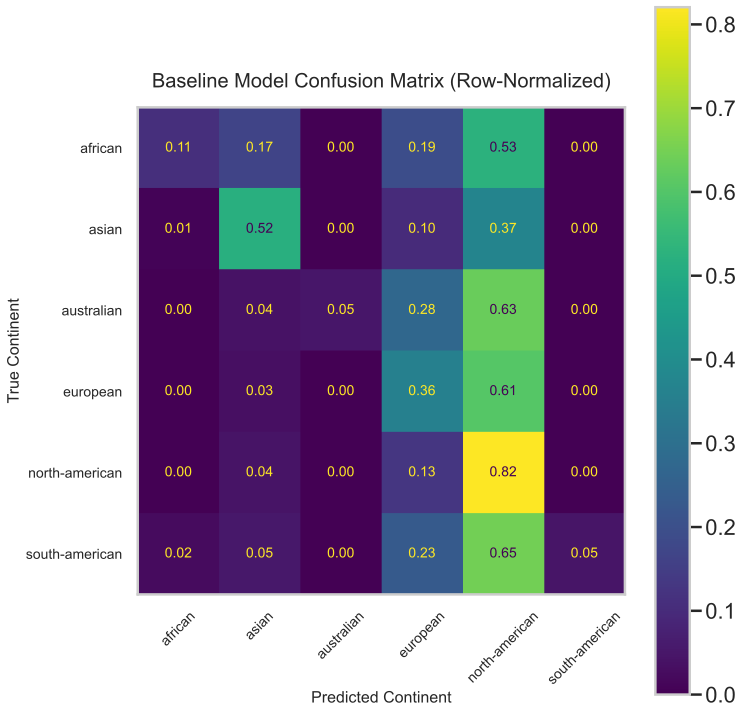

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

classes = baseline_pl.named_steps['RandomForest'].classes_

fig, ax = plt.subplots(figsize=(11, 11))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    labels=classes,
    display_labels=classes,
    normalize='true',             
    values_format=".2f",
    ax=ax,
    xticks_rotation=45,
    text_kw={'fontsize': 14}
)

ax.set_title(
    "Baseline Model Confusion Matrix (Row-Normalized)",
    fontsize=20,
    pad=20
)
ax.set_xlabel("Predicted Continent", fontsize=16)
ax.set_ylabel("True Continent", fontsize=16)

ax.grid(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()


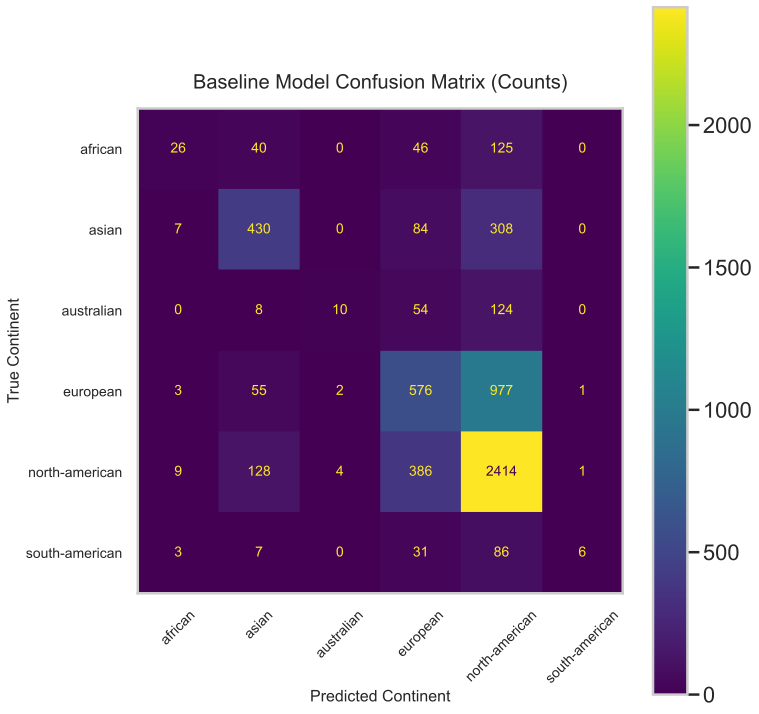

In [ ]:
fig, ax = plt.subplots(figsize=(11, 11))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_baseline,
    labels=classes,
    display_labels=classes,
    normalize=None,             
    # values_format=".2f",
    ax=ax,
    xticks_rotation=45,
    text_kw={'fontsize': 14}
)

ax.set_title(
    "Baseline Model Confusion Matrix (Counts)",
    fontsize=20,
    pad=20
)
ax.set_xlabel("Predicted Continent", fontsize=16)
ax.set_ylabel("True Continent", fontsize=16)

ax.grid(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
print(classification_report(y_test, y_pred_baseline))

                precision    recall  f1-score   support

       african       0.54      0.11      0.18       237
         asian       0.64      0.52      0.57       829
    australian       0.62      0.05      0.09       196
      european       0.49      0.36      0.41      1614
north-american       0.60      0.82      0.69      2942
south-american       0.75      0.05      0.09       133

      accuracy                           0.58      5951
     macro avg       0.61      0.32      0.34      5951
  weighted avg       0.58      0.58      0.55      5951



**Is this a "good" model?**
Our baseline model achieves a macro F1-score of 0.34, which is above random guessing (≈0.17 for six classes) but still relatively low. This indicates that while the model captures some signal, it struggles to perform consistently across all continents. In particular, performance is heavily influenced by class imbalance: the model achieves high recall for the majority class (North American) but performs poorly on minority classes such as Australian and South American recipes, which is reflected in a near-zero recall for these categories. As a result, the macro-averaged F1-score—which weights all classes equally—remains low despite a higher overall accuracy. Therefore, this model is not “good” in the sense of reliable multi-class classification, but it serves as a reasonable baseline that highlights the challenges posed by class imbalance and motivates the need for more balanced features or modeling approaches.

## Step 7: Final Model

### Feature Engineering

Building on our baseline model, we engineered several new features to capture additional patterns in the data:

**New Engineered Features:**

1. **Log-transformed cooking time** (`log_minutes`)
   - **Transformation:** `np.log1p(minutes)` 
   - **Rationale:** Cooking times are highly right-skewed. Log transformation normalizes this distribution and reduces the influence of extreme outliers.

2. **Calorie density** (`calories_per_ingredient`)
   - **Transformation:** `calories / n_ingredients`
   - **Rationale:** This feature captures how calorie-dense each ingredient is on average. Certain cuisines may use richer ingredients (like butter, cream) versus lighter ones (like vegetables), providing a normalized measure of recipe richness.

3. **Nutrition interaction** (`fat_sugar_interaction`)
   - **Transformation:** `total_fat * sugar`
   - **Rationale:** The interaction between fat and sugar content may indicate desserts versus savory dishes. Different continents may have different patterns of combining these macronutrients.

**Additional Processing:**
- Standardized all numerical features using `StandardScaler` to ensure features are on comparable scales
- Retained the `MultiLabelBinarizer` encoding for ingredients from our baseline model


In [ ]:
X['Calorie_density'] = X['calories'].astype(float) / X['n_ingredients'].astype(float)
X['log_ct'] = np.log1p(X['minutes'])
X['nutrition_interaction'] = X['total_fat'].astype(float) * X['sugar'].astype(float)
X

,ingredient_list,minutes,calories,n_steps,...,sugar,Calorie_density,log_ct,nutrition_interaction
0,"[salt, margarine, eggs, vanilla, water]",45,595.1,12,...,211.0,54.10,3.83,9706.0
1,"[butter, sugar, eggs]",120,878.3,7,...,326.0,125.47,4.80,20538.0
2,"[water, salt, pork, ginger]",195,160.4,5,...,0.0,32.08,5.28,0.0
...,...,...,...,...,...,...,...,...,...
29749,"[zucchini, celery, carrot, chives, parsley, to...",8,24.1,2,...,10.0,2.41,2.20,0.0
29750,"[mustard, zucchini, salt, oil, tomatoes, cucum...",15,278.8,6,...,72.0,18.59,2.77,504.0
29751,"[polenta, zucchini, eggs, chives, dill, feta]",80,536.4,21,...,19.0,41.26,4.39,1121.0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import GridSearchCV


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X.drop('minutes', axis=1), y, test_size=0.2, random_state=42)

In [ ]:
final_preproc = ColumnTransformer(
    transformers=[
        ('MLB', MultiLabelBinarizerTransformer(), 'ingredient_list'),
        ('num', StandardScaler(), ['calories', 'n_steps', 'total_fat',
                                   'sugar', 'Calorie_density', 'log_ct', 
                                   'nutrition_interaction'])
    ],
)

In [ ]:
final_pl = Pipeline([
    ('preprocess', final_preproc),
    ('RandomForest', RandomForestClassifier())
])

In [ ]:
final_pl.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('MLB',
                                                  MultiLabelBinarizerTransformer(),
                                                  'ingredient_list'),
                                                 ('num', StandardScaler(),
                                                  ['calories', 'n_steps',
                                                   'total_fat', 'sugar',
                                                   'Calorie_density', 'log_ct',
                                                   'nutrition_interaction'])])),
                ('RandomForest', RandomForestClassifier())])

In [ ]:
final_pl.score(X_test, y_test)

c:\Users\colem\.local\share\mamba\envs\dsc80\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning:

unknown class(es) ['advocaat', 'ahi', 'alum', 'armagnac', 'benedictine', 'breadfruit', 'buffalo', 'burritos', 'candlenuts', 'fryer', 'fudge', 'gomashio', 'graviera', 'huacatay', 'kumquat', 'mahlepi', 'masticha', 'mulberries', 'pierogies', 'pimms', 'porter', 'quahogs', 'quail', 'radiatore', 'rib', 'salsify', 'saltwort', 'samp', 'sangria', 'saunf', 'smokies', 'sopressata', 'spearmint', 'spelt', 'tartaric', 'terrapins', 'truvia', 'veg-all'] will be ignored



0.5943538901025038

## Hyperparameter Tuning
**We will tune the following hyperparameters for the Random Forest Classifier:**

1. **n_estimators**
2. **max_depth** 
3. **min_samples_split** 
4. **criterion**: 

**Why GridSearchCV?**
We use GridSearchCV with 3-fold cross-validation to systematically explore all hyperparameter combinations and select the best performing model based on our training data, avoiding overfitting to a single train-validation split.

In [ ]:
hyperparameters = {
    'RandomForest__criterion': ['gini'],
    'RandomForest__max_depth': [None],
    'RandomForest__max_features': ['sqrt'],
    'RandomForest__min_samples_split': [50, 100],
    'RandomForest__n_estimators': [10, 50, 100],
    'RandomForest__class_weight': ['balanced_subsample', 'balanced']
    # 'RandomForest__min_samples_split': [50],
    # 'RandomForest__n_estimators': [10, 20]
}

In [ ]:
searcher = GridSearchCV(
    final_pl, 
    hyperparameters, 
    cv=3, 
    scoring='f1_macro', 
    verbose=2,
    n_jobs=-1
)

In [ ]:
searcher.fit(X_train, y_train)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('MLB',
                                                                         MultiLabelBinarizerTransformer(),
                                                                         'ingredient_list'),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['calories',
                                                                          'n_steps',
                                                                          'total_fat',
                                                                          'sugar',
                                                                          'Calorie_density',
                                                                          'log_ct',
                                                                          'nutrition_interaction'])])),
                                       ('RandomForest',
                                        RandomForestClassifier())]),
             n_jobs=-1,
             param_grid={'RandomForest__class_weight': ['balanced_subsample',
                                                        'balanced'],
                         'RandomForest__criterion': ['gini'],
                         'RandomForest__max_depth': [None],
                         'RandomForest__max_features': ['sqrt'],
                         'RandomForest__min_samples_split': [50, 100],
                         'RandomForest__n_estimators': [10, 50, 100]},
             scoring='f1_macro', verbose=2)

In [ ]:
print(f"Best hyperparameters: {searcher.best_params_}")
print(f"Best cross-validation F1-score: {searcher.best_score_:.4f}")

Best hyperparameters: {'RandomForest__class_weight': 'balanced_subsample', 'RandomForest__criterion': 'gini', 'RandomForest__max_depth': None, 'RandomForest__max_features': 'sqrt', 'RandomForest__min_samples_split': 50, 'RandomForest__n_estimators': 100}
Best cross-validation F1-score: 0.3666


In [ ]:
y_pred_final = searcher.predict(X_test)
final_f1 = f1_score(y_test, y_pred_final, average='macro')

print(f"\n{'='*50}")
print(f"BASELINE F1-Score (macro): {baseline_f1:.4f}")
print(f"FINAL F1-Score (macro):    {final_f1:.4f}")
print(f"Improvement:               {final_f1 - baseline_f1:.4f}")
print(f"{'='*50}\n")

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_final))

c:\Users\colem\.local\share\mamba\envs\dsc80\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning:

unknown class(es) ['advocaat', 'ahi', 'alum', 'armagnac', 'benedictine', 'breadfruit', 'buffalo', 'burritos', 'candlenuts', 'fryer', 'fudge', 'gomashio', 'graviera', 'huacatay', 'kumquat', 'mahlepi', 'masticha', 'mulberries', 'pierogies', 'pimms', 'porter', 'quahogs', 'quail', 'radiatore', 'rib', 'salsify', 'saltwort', 'samp', 'sangria', 'saunf', 'smokies', 'sopressata', 'spearmint', 'spelt', 'tartaric', 'terrapins', 'truvia', 'veg-all'] will be ignored




BASELINE F1-Score (macro): 0.3402
FINAL F1-Score (macro):    0.3770
Improvement:               0.0368

                precision    recall  f1-score   support

       african       0.21      0.34      0.26       237
         asian       0.47      0.64      0.54       829
    australian       0.21      0.26      0.23       196
      european       0.47      0.56      0.51      1614
north-american       0.71      0.52      0.60      2942
south-american       0.11      0.14      0.12       133

      accuracy                           0.52      5951
     macro avg       0.36      0.41      0.38      5951
  weighted avg       0.56      0.52      0.53      5951



c:\Users\colem\.local\share\mamba\envs\dsc80\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning:

unknown class(es) ['advocaat', 'ahi', 'alum', 'armagnac', 'benedictine', 'breadfruit', 'buffalo', 'burritos', 'candlenuts', 'fryer', 'fudge', 'gomashio', 'graviera', 'huacatay', 'kumquat', 'mahlepi', 'masticha', 'mulberries', 'pierogies', 'pimms', 'porter', 'quahogs', 'quail', 'radiatore', 'rib', 'salsify', 'saltwort', 'samp', 'sangria', 'saunf', 'smokies', 'sopressata', 'spearmint', 'spelt', 'tartaric', 'terrapins', 'truvia', 'veg-all'] will be ignored



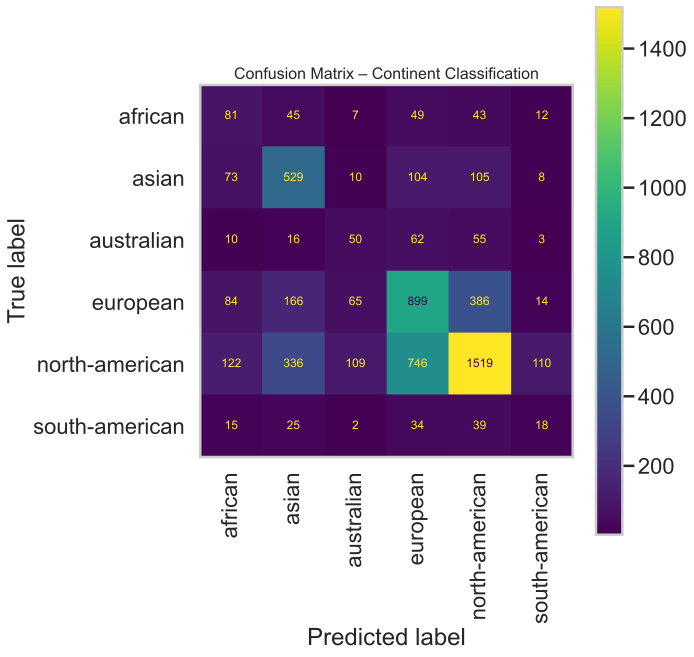

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_final = searcher.predict(X_test)

classes = searcher.best_estimator_.named_steps['RandomForest'].classes_

fig, ax = plt.subplots(figsize=(10, 10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    labels=classes,
    display_labels=classes,
    xticks_rotation=90,
    normalize=None,      
    ax=ax,
    text_kw={'fontsize': 12}
)

ax.grid(False)
ax.set_title("Confusion Matrix – Continent Classification", fontsize=16)
plt.tight_layout()
plt.show()


### Analysis: Why Performance Increased

While the final model did not improve on the baseline greatly, tehre was still an improvement. We can see the fiagonal entries in the confusion matrix for correct predictions is much higher. We can also see that the model doesn't simply predict North America as much. The recall in the continents with fewer recipes increased. The most common prediction for recipes from Africa, Asia, Europe, and North America are their correct labels. The model still has difficult correctly predicting Australia and South America, which are unsurprisingly the continents with the least data. While the scores and metrics don't show a huge improvement, the confusion matrix shows promising results.

Clearly there are some standout issues with how both models predict.

For instance, The confusion matrices for both models show a bias toward predicting North America.

### Potential Improvements for Future Work

To improve upon our model, we could: 1) **Try different feature engineering:** Creating binary indicators for signature ingredients (e.g., "has_soy_sauce" for Asian), using TF-IDF on ingredients instead of MultiLabelBinarizer 2) **Experiment with different algorithms:** Gradient boosting (XGBoost, LightGBM) showed up online when we were researching on how to improve the model. They may handle imbalance better

## Step 8: Fairness Analysis

### Research Question

Does our final model perform differently for recipes with **short cooking times** versus **long cooking times**?

This is an important fairness question because if our model systematically performs worse for quick recipes (which may be more accessible to busy home cooks) or time-intensive recipes (which may represent more traditional, culturally significant dishes), it could perpetuate biases in how different culinary traditions are represented and recommended.

### Group Definitions

We define our two groups by binarizing cooking time at the median:

- **Group X (Short Cooking Time):** Recipes with cooking time ≤ 40 minutes (median)
- **Group Y (Long Cooking Time):** Recipes with cooking time > 40 minutes

We chose the median as our threshold because it creates balanced groups, ensuring we have sufficient sample sizes for both groups to make meaningful statistical comparisons.

### Evaluation Metric

**Metric:** Precision (macro-averaged across all continents)

We chose precision as our fairness metric because it measures the proportion of correct predictions among all predictions made for each continent. In the context of fairness:
- High precision means when our model predicts a recipe is from a specific continent, it's usually correct
- Low precision means our model makes more false positive errors, potentially misattributing recipes to the wrong cultural origin

This is particularly important for fairness because **incorrect attribution of recipes to the wrong continent could be seen as cultural misappropriation or erasure**. We want to ensure our model doesn't systematically misclassify recipes from certain cooking time groups.

### Hypotheses

- **Null Hypothesis (H₀):** Our model is fair. Its precision for short cooking time recipes and long cooking time recipes are roughly the same, and any differences are due to random chance.

- **Alternative Hypothesis (H₁):** Our model is unfair. Its precision for short cooking time recipes is different from its precision for long cooking time recipes.

**Test Statistic:** Absolute difference in precision between short and long cooking time groups

We use a two-tailed test (checking for any difference, not just one direction) because we have no prior expectation about which group might be disadvantaged.

**Significance Level:** α = 0.05

In [ ]:
from sklearn.metrics import precision_score
import numpy as np
import pandas as pd
from tqdm import trange

In [ ]:
median_minutes = continent_recipes['minutes'].median()
cooking_time_group = (continent_recipes['minutes'] > median_minutes).astype(int)

X_test_with_group = X_test.copy()
X_test_with_group['cooking_time_group'] = cooking_time_group.loc[X_test.index]

In [ ]:
y_pred_final = searcher.predict(X_test)

c:\Users\colem\.local\share\mamba\envs\dsc80\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning:

unknown class(es) ['advocaat', 'ahi', 'alum', 'armagnac', 'benedictine', 'breadfruit', 'buffalo', 'burritos', 'candlenuts', 'fryer', 'fudge', 'gomashio', 'graviera', 'huacatay', 'kumquat', 'mahlepi', 'masticha', 'mulberries', 'pierogies', 'pimms', 'porter', 'quahogs', 'quail', 'radiatore', 'rib', 'salsify', 'saltwort', 'samp', 'sangria', 'saunf', 'smokies', 'sopressata', 'spearmint', 'spelt', 'tartaric', 'terrapins', 'truvia', 'veg-all'] will be ignored



In [ ]:
eval_df = pd.DataFrame({
    'cooking_time_group': X_test_with_group['cooking_time_group'],
    'y_true': y_test,
    'y_pred': y_pred_final
})

In [ ]:
def calculate_precision_difference(df):
    short_time = df[df['cooking_time_group'] == 0]
    long_time = df[df['cooking_time_group'] == 1]
    
    precision_short = precision_score(short_time['y_true'], 
                                      short_time['y_pred'], 
                                      average='macro',
                                      zero_division=0)
    precision_long = precision_score(long_time['y_true'], 
                                     long_time['y_pred'], 
                                     average='macro',
                                     zero_division=0)
    
    return abs(precision_short - precision_long)

observed_difference = calculate_precision_difference(eval_df)
print(f"Observed difference in precision: {observed_difference:.4f}")

n_repetitions = 1000
differences = []

for _ in trange(n_repetitions):
    shuffled_df = eval_df.copy()
    shuffled_df['cooking_time_group'] = \
        np.random.permutation(shuffled_df['cooking_time_group'])
    
    differences.append(calculate_precision_difference(shuffled_df))

differences = np.array(differences)

p_value = np.mean(differences >= observed_difference)
print(f"P-value: {p_value:.4f}")

Observed difference in precision: 0.0153


100%|██████████| 1000/1000 [00:30<00:00, 32.66it/s]

P-value: 0.3350


In [ ]:
fig = px.histogram(
    x=differences,
    nbins=50,
    title="Null Distribution of Absolute Difference in " \
    "Precision<br>Between Short and Long Cooking Time Recipes",
    labels={"x": "Absolute Difference in Precision", "count": "Count"},
    width=1000,
    height=500
)

fig.add_vline(x=observed_difference, line_color="red", line_width=3)
fig.add_annotation(
    x=observed_difference,
    y=0.95, 
    xref="x", 
    yref="paper",
    text="<span style='color:red'>Observed difference</span>",
    showarrow=False
)

fig.show()

In [ ]:
def precision_by_group_table(eval_df, group_col='cooking_time_group'):
    n_total = len(eval_df)
    rows = []

    for g, gdf in eval_df.groupby(group_col):
        prec = precision_score(
            gdf['y_true'], gdf['y_pred'],
            average='macro',
            zero_division=0
        )
        rows.append({
            "Group": g,
            "Precision (macro)": prec,
            "Support": len(gdf),
            "Sample Size": len(gdf) / n_total
        })

    out = pd.DataFrame(rows).sort_values("Group").reset_index(drop=True)

    out["Group"] = out["Group"].map({0: "Short Cooking Time", 1: "Long Cooking Time"}).fillna(out["Group"])

    if len(out) == 2:
        diff = abs(out.loc[0, "Precision (macro)"] - out.loc[1, "Precision (macro)"])
        out = pd.concat([out, pd.DataFrame([{
            "Group": "Difference",
            "Precision (macro)": diff,
            "Support": np.nan,
            "Sample Size": np.nan
        }])], ignore_index=True)

    out["Precision (macro)"] = out["Precision (macro)"].map(lambda x: f"{x:.4f}" if pd.notna(x) else x)
    out["Sample Size"] = out["Sample Size"].map(lambda x: f"{x:.0%}" if pd.notna(x) else x)

    return out

precision_table = precision_by_group_table(eval_df)
precision_table


,Group,Precision (macro),Support,Sample Size
0,Short Cooking Time,0.3597,3240.0,54%
1,Long Cooking Time,0.3750,2711.0,46%
2,Difference,0.0153,NaN,NaN


### Conclusion

With a p-value of 0.3350, which exceeds our significance level of α = 0.05, we **fail to reject the null hypothesis** and do not find statistically significant evidence that the model’s precision differs between recipes with short versus long cooking times.

Overall, this analysis provides **no strong evidence of unfairness with respect to cooking time**: the model does not appear to systematically favor quick recipes over more time-intensive ones, or vice versa, in terms of precision. However, failing to reject the null hypothesis does not guarantee fairness. This conclusion is limited to a single performance metric (macro precision) and a single grouping variable, and the test may lack sufficient power to detect more subtle disparities, particularly given class imbalance in the dataset. A more comprehensive fairness assessment would require examining additional metrics (e.g., recall or F1-score) and other potential sources of bias, such as recipe complexity or ingredient availability.